# Inspect the Generated Distractor Datasets

In [2]:
import json
import re
import math

import torch
import numpy as np

import matplotlib.pyplot as plt

In [3]:
with open("data/datasets/am/icl/500/distractors.json", "r+") as f:
    data = json.load(f)
    print(f"Loaded dataset of {len(data)} MWPs")

Loaded dataset of 500 MWPs


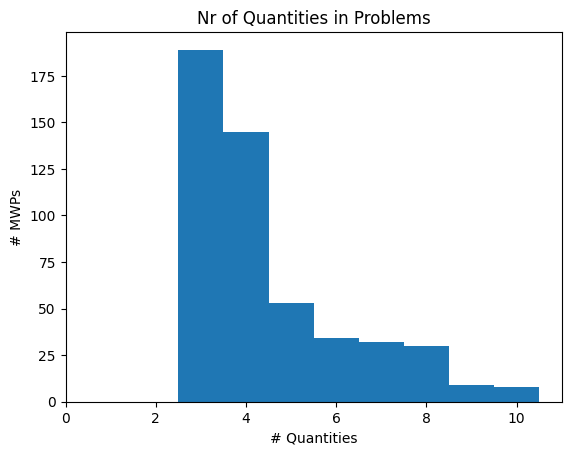

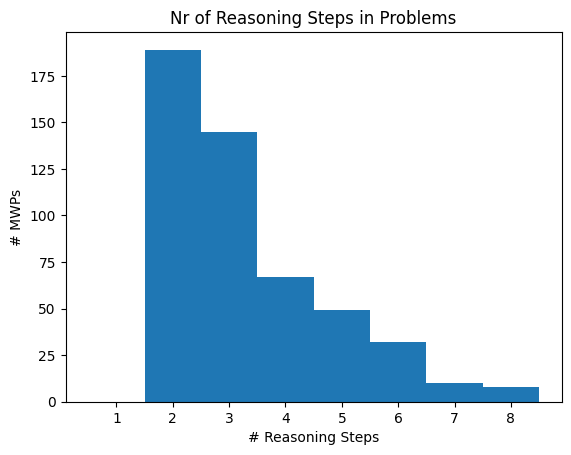

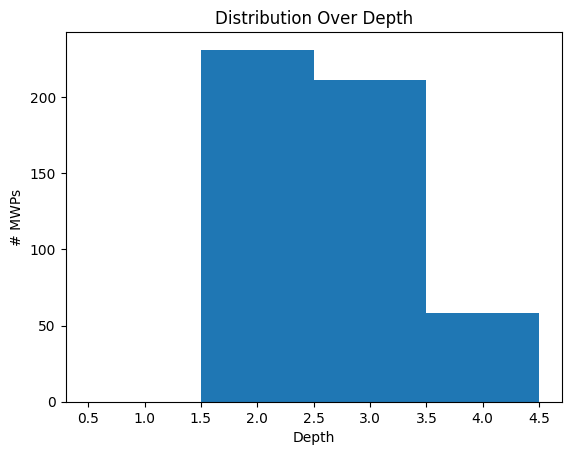

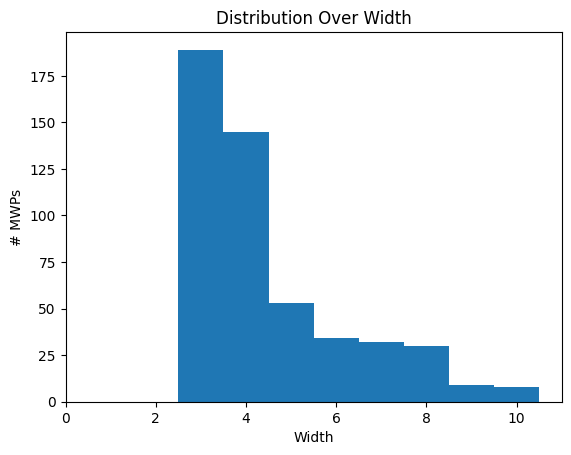

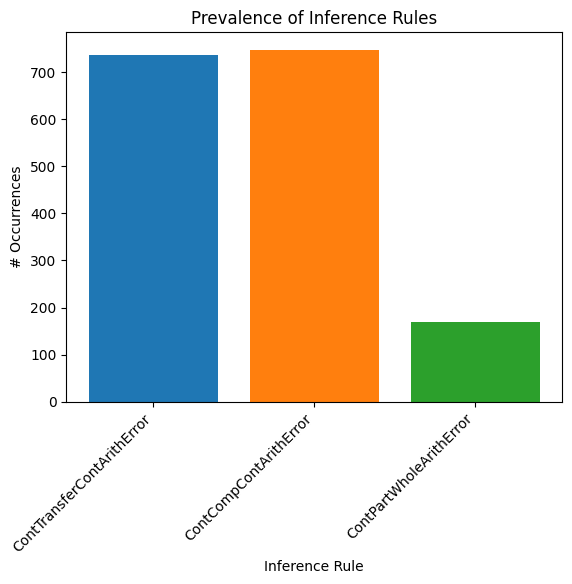

# Problems without Compeq 500/500


In [3]:
# nr of quantities per MWP
quants = []
nr_steps = []
depths = []
widths = []
rule_cnts = {}
nr_problems_without_compeq = 0
for mwp_id in data:
    mwp_data = data[mwp_id]
    
    for num_inst in mwp_data["instantiations"]:
        num_inst_data = mwp_data["instantiations"][num_inst]
        num_quant = len(num_inst_data["instantiation"])
        quants.append(num_quant)
        break

    steps = len(mwp_data["metadata"]["orig_rules_by_conclusion"])
    nr_steps.append(steps)

    depths.append(mwp_data["metadata"]["depth"])
    widths.append(mwp_data["metadata"]["width"])

    for rule in mwp_data["metadata"]["orig_rules_by_conclusion"].values():
        rule_cnts[rule] = rule_cnts.get(rule, 0) + 1

    if "ContCompCompeqCont" not in mwp_data["metadata"]["orig_rules_by_conclusion"].values():
        nr_problems_without_compeq += 1

plt.title("Nr of Quantities in Problems")
plt.xlabel("# Quantities")
plt.ylabel("# MWPs")
plt.hist(quants, align="left", bins=list(range(1, max(quants)+1)))
plt.show()

plt.title("Nr of Reasoning Steps in Problems")
plt.xlabel("# Reasoning Steps")
plt.ylabel("# MWPs")
plt.hist(nr_steps, align="left", bins=list(range(1, max(nr_steps)+1)))
plt.show()

plt.title("Distribution Over Depth")
plt.xlabel("Depth")
plt.ylabel("# MWPs")
plt.hist(depths, align="left", bins=list(range(1, max(depths)+1)))
plt.show()

plt.title("Distribution Over Width")
plt.xlabel("Width")
plt.ylabel("# MWPs")
plt.hist(widths, align="left", bins=list(range(1, max(widths)+1)))
plt.show()

plt.title("Prevalence of Inference Rules")
plt.xlabel("Inference Rule")
plt.xticks(rotation=45, ha="right")
plt.ylabel("# Occurrences")
for r,cnt in rule_cnts.items():
    plt.bar(str(r), cnt)
plt.show()

print(f"# Problems without Compeq {nr_problems_without_compeq}/{len(data)}")

# Remove Op Pert Answers

In [11]:
with open("data/datasets/icl/ls500/llama2_7B_I_s3_instva_nort.json", "r+") as f:
    data = json.load(f)
    print(f"Loaded dataset of {len(data)} MWPs")

Loaded dataset of 500 MWPs


In [12]:
# remove operation perturbation answers from file
for mwp_id in data:
    for inst_id in data[mwp_id]["instantiations"]:
        data[mwp_id]["instantiations"][inst_id]["all_op_perturbation_answers"] = None

In [13]:
with open("data/datasets/icl/ls500/llama2_7B_I_s3_instva_nort.json", "w+") as f:
    json.dump(data, f)

# Add Op Pert Answers

In [4]:
with open("data/datasets/am/icl/100/distractors.json", "r+") as f:
    data = json.load(f)
    print(f"Loaded dataset of {len(data)} MWPs")

Loaded dataset of 100 MWPs


In [5]:
from datageneration.util import compute_all_op_pert_erroneous_answers

for mwp_id in data:
    for inst_id in data[mwp_id]["instantiations"]:
        data[mwp_id]["instantiations"][inst_id]["all_op_perturbation_answers"] = compute_all_op_pert_erroneous_answers(data[mwp_id]["metadata"]["correct_expression"], data[mwp_id]["instantiations"][inst_id]["instantiation"])

In [6]:
with open("data/datasets/am/icl/100/distractors_oppert.json", "w+") as f:
    json.dump(data, f)